# Steady-State Heat Conduction — 2D

We solve two Poisson/Laplace problems on the unit square $[0,1]^2$:

| Case | Equation | BCs | Exact solution |
|------|----------|-----|----------------|
| **Laplace** | $\nabla^2 T = 0$ | $T=1$ left, $T=0$ right, $\partial_n T=0$ top/bottom | $T = 1-x$ |
| **Poisson** | $\nabla^2 T + S = 0$, $\;S = \sin(\pi x)\sin(\pi y)$ | $T=0$ all walls | $T = \dfrac{\sin\pi x\sin\pi y}{2\pi^2}$ |

Both are linear — Newton converges in one step.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')
from upde import PDE
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

nx = ny = 32
x  = np.linspace(0, 1, nx)
y  = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y, indexing='ij')


## Case 1 — 2D Laplace

$$\nabla^2 T = 0, \qquad T(0,y)=1,\; T(1,y)=0, \; \partial_n T = 0 \;\text{top/bottom}$$

Exact: $T = 1 - x$ (uniform in $y$).


In [4]:
eq_lap = PDE('T', x=x, y=y)
eq_lap.add_diffusion(diffusivity=1.0)
eq_lap.set_bc(side='left',   kind='dirichlet', value=1.0)
eq_lap.set_bc(side='right',  kind='dirichlet', value=0.0)
eq_lap.set_bc(side='bottom', kind='neumann',   value=0.0)
eq_lap.set_bc(side='top',    kind='neumann',   value=0.0)

sol_lap = eq_lap.solve_steady()
print(sol_lap)

T_exact = 1.0 - X
print(f"Max error vs exact: {np.max(np.abs(sol_lap.T - T_exact)):.2e}")


SteadySolution(fields=['T'], shape=(32, 32), success=True, residual=1.07e-13, nfev=1038)
Max error vs exact: 1.11e-16


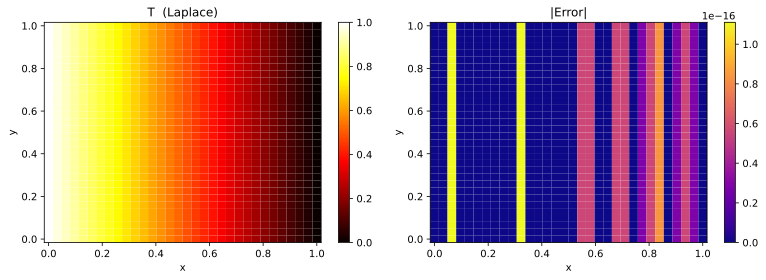

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(X, Y, sol_lap.T, cmap='hot', shading='auto', vmin=0, vmax=1)
axes[0].set(xlabel='x', ylabel='y', title='T  (Laplace)')
plt.colorbar(im, ax=axes[0])

im2 = axes[1].pcolormesh(X, Y, np.abs(sol_lap.T - T_exact), cmap='plasma', shading='auto')
axes[1].set(xlabel='x', ylabel='y', title='|Error|')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


## Case 2 — 2D Poisson with sinusoidal source

$$\nabla^2 T + \sin(\pi x)\sin(\pi y) = 0, \qquad T = 0 \;\text{on all walls}$$

Exact solution: $T = \dfrac{\sin(\pi x)\sin(\pi y)}{2\pi^2}$.


In [6]:
eq_poi = PDE('T', x=x, y=y)
eq_poi.add_diffusion(diffusivity=1.0)
eq_poi.add_source(expr=lambda x, y: np.sin(np.pi * x) * np.sin(np.pi * y))
eq_poi.set_bc(side='left',   kind='dirichlet', value=0.0)
eq_poi.set_bc(side='right',  kind='dirichlet', value=0.0)
eq_poi.set_bc(side='bottom', kind='dirichlet', value=0.0)
eq_poi.set_bc(side='top',    kind='dirichlet', value=0.0)

sol_poi = eq_poi.solve_steady()
print(sol_poi)

T_exact_poi = np.sin(np.pi * X) * np.sin(np.pi * Y) / (2 * np.pi**2)
print(f"Max error vs exact: {np.max(np.abs(sol_poi.T - T_exact_poi)):.2e}")


SteadySolution(fields=['T'], shape=(32, 32), success=False, residual=1.87e-14, nfev=2073)
Max error vs exact: 4.33e-05


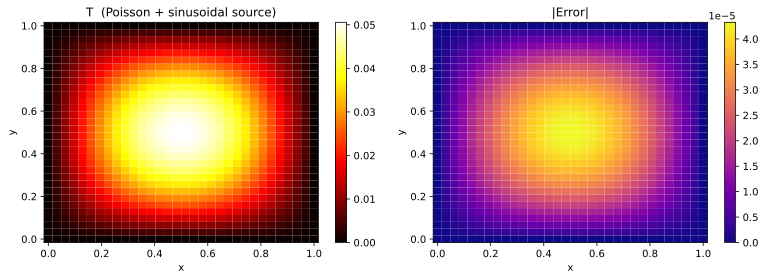

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(X, Y, sol_poi.T, cmap='hot', shading='auto')
axes[0].set(xlabel='x', ylabel='y', title='T  (Poisson + sinusoidal source)')
plt.colorbar(im, ax=axes[0])

im2 = axes[1].pcolormesh(X, Y, np.abs(sol_poi.T - T_exact_poi), cmap='plasma', shading='auto')
axes[1].set(xlabel='x', ylabel='y', title='|Error|')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


## Summary

Errors are at the $O(\Delta x^2)$ discretisation level — the solver adds no additional error.
Both 2D problems solve with a single `solve_steady()` call, no solver parameters needed.
